# 🚢 Titanic - Machine Learning from Disaster
## Phase 11: Cross-Fitted Group Survival Intelligence & Hybrid Optimization

### Objective

Our Kaggle competition results have improved across the project:

| Phase | Submission | Kaggle Public Score |
|---|---|---:|
| Phase 9 | Random Forest | 0.75119 |
| Phase 9 | Weighted Ensemble | 0.75119 |
| Phase 10 | Gender Baseline | 0.76555 |
| Phase 10 | Robust Model | **0.77990** |

Phase 10 demonstrated that stronger feature engineering and more robust validation improved our unseen Kaggle performance.

However, the Titanic dataset contains an important source of information that we have not yet fully modeled:

> Passengers did not travel independently.

Many passengers traveled as:

- Families
- Couples
- Parent-child groups
- Shared-ticket groups
- Larger travel parties

Members of these groups often experienced related survival outcomes.

In Phase 11, we will attempt to capture this information while carefully avoiding target leakage.

---

## Phase 11 Goals

We will:

1. Rebuild robust Titanic-specific structural features.
2. Identify family and ticket-based passenger groups.
3. Generate **cross-fitted group survival features** for training passengers.
4. Generate corresponding group survival features for test passengers using training labels only.
5. Measure the coverage and reliability of these group signals.
6. Train multiple regularized models.
7. Generate out-of-fold predictions.
8. Compare models using both accuracy and log loss.
9. Build probability ensembles.
10. Test conservative Titanic-specific post-processing.
11. Generate several carefully selected Kaggle submissions.

---

## Critical Leakage Rule

A training passenger must never receive a group survival feature calculated using their own target label.

For training data, group survival statistics will therefore be generated **out-of-fold**.

For test data, group survival statistics may be calculated using matching passengers from the labeled training dataset.

At no point will we use unknown test survival labels.

This distinction is essential for producing realistic validation results.

---

## Competition Benchmark

Our current best Kaggle Public Score is:

**0.77990**

Every Phase 11 submission will be compared against this benchmark.

Our objective is not simply to maximize local cross-validation accuracy.

Our objective is to discover patterns that generalize to the unseen Kaggle test passengers.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import (
    StratifiedKFold
)

from sklearn.compose import (
    ColumnTransformer
)

from sklearn.pipeline import (
    Pipeline
)

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import (
    SimpleImputer
)

from sklearn.base import (
    clone
)

from sklearn.linear_model import (
    LogisticRegression
)

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestRegressor
)

from sklearn.metrics import (
    accuracy_score,
    log_loss,
    confusion_matrix,
    classification_report
)

import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. Define Project Paths

Phase 11 will rebuild the required features directly from the original Kaggle data.

This is intentional.

Group-survival features depend on:

- Passenger names
- Surnames
- Family relationships
- Ticket numbers

Using the raw data ensures that the complete feature-generation process remains reproducible.

In [2]:
raw_data_dir = Path(
    "../data/raw"
)

results_dir = Path(
    "../results"
)

submissions_dir = Path(
    "../submissions"
)

models_dir = Path(
    "../models"
)


results_dir.mkdir(
    parents=True,
    exist_ok=True
)

submissions_dir.mkdir(
    parents=True,
    exist_ok=True
)

models_dir.mkdir(
    parents=True,
    exist_ok=True
)


print("Project directories configured.")

Project directories configured.


In [3]:
train_raw = pd.read_csv(
    raw_data_dir / "train.csv"
)

test_raw = pd.read_csv(
    raw_data_dir / "test.csv"
)


print(
    f"Train shape: {train_raw.shape}"
)

print(
    f"Test shape: {test_raw.shape}"
)


assert "Survived" in train_raw.columns
assert "Survived" not in test_raw.columns

assert train_raw["PassengerId"].is_unique
assert test_raw["PassengerId"].is_unique


train_raw.head()

Train shape: (891, 12)
Test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
y = train_raw[
    "Survived"
].astype(int).copy()


test_passenger_ids = test_raw[
    "PassengerId"
].copy()


print(
    f"Training passengers: {len(y)}"
)

print(
    f"Test passengers: {len(test_passenger_ids)}"
)

Training passengers: 891
Test passengers: 418


# 3. Build Structural Features

Train and test data will temporarily be combined to calculate features that do not depend on `Survived`.

Examples include:

- Ticket group size
- Family group size
- Ticket frequency
- Cabin deck
- Fare per passenger

Combining the passenger manifest allows us to identify groups that span both the Kaggle training and test datasets.

This does not introduce target leakage because no survival labels are used during this step.

In [5]:
train_base = train_raw.drop(
    columns=["Survived"]
).copy()


test_base = test_raw.copy()


train_base["Dataset"] = "train"

test_base["Dataset"] = "test"


combined = pd.concat(

    [
        train_base,
        test_base
    ],

    ignore_index=True
)


print(
    f"Combined passenger manifest: "
    f"{combined.shape}"
)

Combined passenger manifest: (1309, 12)


In [6]:
combined["Title"] = (

    combined["Name"]

    .str.extract(
        r",\s*([^.]*)\."
    )[0]

    .str.strip()
)


title_mapping = {

    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs",

    "Lady": "Rare",
    "Countess": "Rare",
    "Capt": "Rare",
    "Col": "Rare",
    "Don": "Rare",
    "Dr": "Rare",
    "Major": "Rare",
    "Rev": "Rare",
    "Sir": "Rare",
    "Jonkheer": "Rare",
    "Dona": "Rare"
}


combined["Title"] = (

    combined["Title"]

    .replace(
        title_mapping
    )
)


combined["Title"].value_counts()

Title
Mr              757
Miss            264
Mrs             198
Master           61
Rare             28
the Countess      1
Name: count, dtype: int64

In [7]:
combined["Surname"] = (

    combined["Name"]

    .str.split(",")

    .str[0]

    .str.strip()

    .str.upper()
)


combined[
    [
        "Name",
        "Surname"
    ]
].head()

,Name,Surname
0,"Braund, Mr. Owen Harris",BRAUND
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",CUMINGS
2,"Heikkinen, Miss. Laina",HEIKKINEN
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",FUTRELLE
4,"Allen, Mr. William Henry",ALLEN


In [8]:
combined["FamilySize"] = (

    combined["SibSp"]

    +

    combined["Parch"]

    +

    1
)


combined["IsAlone"] = (

    combined["FamilySize"]
    == 1

).astype(int)


combined["FamilyCategory"] = pd.cut(

    combined["FamilySize"],

    bins=[
        0,
        1,
        4,
        7,
        np.inf
    ],

    labels=[
        "Alone",
        "Small",
        "Medium",
        "Large"
    ]
)

# 4. Construct Family Groups

Surname alone can be ambiguous.

Instead, we define a family group using:

`Surname + FamilySize`

For example:

`ANDERSSON_7`

This provides a stronger approximation of a passenger's immediate family group.

The identifier will be used primarily to construct group survival statistics.

It will not be directly one-hot encoded as a model feature because its high cardinality could encourage memorization.

In [9]:
combined["FamilyID"] = (

    combined["Surname"]

    +

    "_"

    +

    combined[
        "FamilySize"
    ].astype(str)
)


family_manifest_counts = (

    combined[
        "FamilyID"
    ]

    .value_counts()
)


combined[
    "FamilyManifestSize"
] = (

    combined[
        "FamilyID"
    ]

    .map(
        family_manifest_counts
    )
)


combined[
    [
        "Surname",
        "FamilySize",
        "FamilyID",
        "FamilyManifestSize"
    ]
].head()

,Surname,FamilySize,FamilyID,FamilyManifestSize
0,BRAUND,2,BRAUND_2,2
1,CUMINGS,2,CUMINGS_2,2
2,HEIKKINEN,1,HEIKKINEN_1,1
3,FUTRELLE,2,FUTRELLE_2,2
4,ALLEN,1,ALLEN_1,2


In [10]:
combined["TicketClean"] = (

    combined["Ticket"]

    .astype(str)

    .str.upper()

    .str.replace(
        r"\s+",
        "",
        regex=True
    )

    .str.strip()
)


ticket_manifest_counts = (

    combined[
        "TicketClean"
    ]

    .value_counts()
)


combined["TicketGroupSize"] = (

    combined[
        "TicketClean"
    ]

    .map(
        ticket_manifest_counts
    )
)


combined["SharedTicket"] = (

    combined[
        "TicketGroupSize"
    ]
    > 1

).astype(int)

In [11]:
combined["TicketPrefix"] = (

    combined["Ticket"]

    .astype(str)

    .str.upper()

    .str.replace(
        r"\d",
        "",
        regex=True
    )

    .str.replace(
        r"[\s./]",
        "",
        regex=True
    )
)


combined["TicketPrefix"] = (

    combined[
        "TicketPrefix"
    ]

    .replace(
        "",
        "NONE"
    )
)

In [12]:
combined["AgeMissing"] = (

    combined["Age"]

    .isna()

).astype(int)


age_medians = (

    combined

    .groupby(
        [
            "Title",
            "Pclass",
            "Sex"
        ]
    )[
        "Age"
    ]

    .transform(
        "median"
    )
)


combined["Age"] = (

    combined["Age"]

    .fillna(
        age_medians
    )

    .fillna(

        combined[
            "Age"
        ].median()
    )
)

In [13]:
combined["Child"] = (

    combined["Age"]
    < 16

).astype(int)


combined["YoungChild"] = (

    combined["Age"]
    < 10

).astype(int)


combined["Woman"] = (

    (
        combined["Sex"]
        == "female"
    )

    &

    (
        combined["Age"]
        >= 16
    )

).astype(int)


combined["AdultMale"] = (

    (
        combined["Sex"]
        == "male"
    )

    &

    (
        combined["Age"]
        >= 16
    )

).astype(int)


combined["Boy"] = (

    (
        combined["Sex"]
        == "male"
    )

    &

    (
        combined["Age"]
        < 16
    )

).astype(int)


combined["Mother"] = (

    (
        combined["Sex"]
        == "female"
    )

    &

    (
        combined["Age"]
        > 18
    )

    &

    (
        combined["Parch"]
        > 0
    )

    &

    (
        combined["Title"]
        != "Miss"
    )

).astype(int)

In [14]:
combined["Fare"] = (

    combined["Fare"]

    .fillna(

        combined[
            "Fare"
        ].median()
    )
)


combined["FarePerPerson"] = (

    combined["Fare"]

    /

    combined["TicketGroupSize"]
)


combined["LogFare"] = (

    np.log1p(

        combined["Fare"]
    )
)

In [15]:
combined["CabinKnown"] = (

    combined["Cabin"]

    .notna()

).astype(int)


combined["Deck"] = (

    combined["Cabin"]

    .fillna(
        "Unknown"
    )

    .astype(str)

    .str[0]
)

In [16]:
combined["Sex_Pclass"] = (

    combined["Sex"].astype(str)

    +

    "_"

    +

    combined["Pclass"].astype(str)
)


combined["Title_Pclass"] = (

    combined["Title"].astype(str)

    +

    "_"

    +

    combined["Pclass"].astype(str)
)


combined["FamilyClass"] = (

    combined["FamilyCategory"].astype(str)

    +

    "_"

    +

    combined["Pclass"].astype(str)
)

In [17]:
train_struct = (

    combined[

        combined["Dataset"]
        == "train"

    ]

    .copy()

    .reset_index(
        drop=True
    )
)


test_struct = (

    combined[

        combined["Dataset"]
        == "test"

    ]

    .copy()

    .reset_index(
        drop=True
    )
)


assert len(train_struct) == len(train_raw)

assert len(test_struct) == len(test_raw)


print(
    train_struct.shape,
    test_struct.shape
)

(891, 37) (418, 37)


# 5. Analyze Train-Test Group Overlap

Group survival intelligence is only useful for test passengers whose family or ticket groups overlap with labeled training passengers.

We will therefore measure:

- How many test passengers share a family group with training passengers.
- How many test passengers share a ticket with training passengers.

This tells us how much of the Kaggle test set can potentially benefit from group survival signals.

In [18]:
train_family_ids = set(

    train_struct[
        "FamilyID"
    ]
)


train_ticket_ids = set(

    train_struct[
        "TicketClean"
    ]
)


test_struct[
    "FamilySeenInTrain"
] = (

    test_struct[
        "FamilyID"
    ]

    .isin(
        train_family_ids
    )

).astype(int)


test_struct[
    "TicketSeenInTrain"
] = (

    test_struct[
        "TicketClean"
    ]

    .isin(
        train_ticket_ids
    )

).astype(int)


print(
    "Test passengers with family overlap:",
    test_struct[
        "FamilySeenInTrain"
    ].sum()
)


print(
    "Test passengers with ticket overlap:",
    test_struct[
        "TicketSeenInTrain"
    ].sum()
)

Test passengers with family overlap: 168
Test passengers with ticket overlap: 152


# 6. Cross-Fitted Group Survival Features

This is the most important part of Phase 11.

Suppose Passenger A and Passenger B belong to the same family.

If we calculate:

`Family Survival Rate`

using the entire training dataset, Passenger A's own `Survived` value contributes to Passenger A's feature.

That is target leakage.

Instead, for every validation fold:

1. Calculate group survival statistics using only the fold's training portion.
2. Map those statistics to the validation portion.
3. Never allow a validation passenger's target to contribute to their own feature.

For the final Kaggle test dataset:

1. Use all labeled training passengers.
2. Calculate family and ticket survival statistics.
3. Map them to matching test passengers.

This mirrors the information genuinely available when predicting unseen passengers.

In [19]:
def create_cross_fitted_group_feature(
    train_df,
    test_df,
    target,
    group_column,
    cv,
    smoothing=5.0
):

    global_mean = target.mean()


    oof_values = np.full(
        len(train_df),
        global_mean,
        dtype=float
    )


    oof_counts = np.zeros(
        len(train_df),
        dtype=float
    )


    for train_idx, valid_idx in cv.split(
        train_df,
        target
    ):

        fold_train = train_df.iloc[
            train_idx
        ].copy()


        fold_valid = train_df.iloc[
            valid_idx
        ].copy()


        fold_train[
            "_target_"
        ] = target.iloc[
            train_idx
        ].values


        group_stats = (

            fold_train

            .groupby(
                group_column
            )[
                "_target_"
            ]

            .agg(
                [
                    "mean",
                    "count"
                ]
            )
        )


        smoothed_mean = (

            (
                group_stats["mean"]
                *
                group_stats["count"]
            )

            +

            (
                global_mean
                *
                smoothing
            )

        ) / (

            group_stats["count"]
            +
            smoothing
        )


        mapped_mean = (

            fold_valid[
                group_column
            ]

            .map(
                smoothed_mean
            )

            .fillna(
                global_mean
            )
        )


        mapped_count = (

            fold_valid[
                group_column
            ]

            .map(
                group_stats["count"]
            )

            .fillna(
                0
            )
        )


        oof_values[
            valid_idx
        ] = mapped_mean.values


        oof_counts[
            valid_idx
        ] = mapped_count.values


    full_train = train_df.copy()


    full_train[
        "_target_"
    ] = target.values


    full_stats = (

        full_train

        .groupby(
            group_column
        )[
            "_target_"
        ]

        .agg(
            [
                "mean",
                "count"
            ]
        )
    )


    full_smoothed_mean = (

        (
            full_stats["mean"]
            *
            full_stats["count"]
        )

        +

        (
            global_mean
            *
            smoothing
        )

    ) / (

        full_stats["count"]
        +
        smoothing
    )


    test_values = (

        test_df[
            group_column
        ]

        .map(
            full_smoothed_mean
        )

        .fillna(
            global_mean
        )

        .values
    )


    test_counts = (

        test_df[
            group_column
        ]

        .map(
            full_stats["count"]
        )

        .fillna(
            0
        )

        .values
    )


    return (
        oof_values,
        test_values,
        oof_counts,
        test_counts
    )

In [20]:
feature_cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)


(
    family_survival_oof,
    family_survival_test,
    family_known_count_oof,
    family_known_count_test

) = create_cross_fitted_group_feature(

    train_df=train_struct,

    test_df=test_struct,

    target=y,

    group_column="FamilyID",

    cv=feature_cv,

    smoothing=3.0
)

In [21]:
(
    ticket_survival_oof,
    ticket_survival_test,
    ticket_known_count_oof,
    ticket_known_count_test

) = create_cross_fitted_group_feature(

    train_df=train_struct,

    test_df=test_struct,

    target=y,

    group_column="TicketClean",

    cv=feature_cv,

    smoothing=3.0
)

In [22]:
train_struct[
    "FamilySurvivalSignal"
] = family_survival_oof


test_struct[
    "FamilySurvivalSignal"
] = family_survival_test


train_struct[
    "TicketSurvivalSignal"
] = ticket_survival_oof


test_struct[
    "TicketSurvivalSignal"
] = ticket_survival_test


train_struct[
    "FamilyKnownCount"
] = family_known_count_oof


test_struct[
    "FamilyKnownCount"
] = family_known_count_test


train_struct[
    "TicketKnownCount"
] = ticket_known_count_oof


test_struct[
    "TicketKnownCount"
] = ticket_known_count_test

# 7. Group Signal Reliability

A group survival estimate based on several known passengers is more reliable than one based on a single passenger.

Therefore, we will explicitly provide the model with:

- Number of known family members.
- Number of known ticket-group members.
- Whether a reliable family signal exists.
- Whether a reliable ticket signal exists.

This allows the model to determine how much confidence to place in each group statistic.

In [23]:
train_struct[
    "FamilySignalAvailable"
] = (

    train_struct[
        "FamilyKnownCount"
    ]
    > 0

).astype(int)


test_struct[
    "FamilySignalAvailable"
] = (

    test_struct[
        "FamilyKnownCount"
    ]
    > 0

).astype(int)


train_struct[
    "TicketSignalAvailable"
] = (

    train_struct[
        "TicketKnownCount"
    ]
    > 0

).astype(int)


test_struct[
    "TicketSignalAvailable"
] = (

    test_struct[
        "TicketKnownCount"
    ]
    > 0

).astype(int)

In [24]:
def weighted_group_signal(df):

    family_weight = df[
        "FamilyKnownCount"
    ]


    ticket_weight = df[
        "TicketKnownCount"
    ]


    total_weight = (

        family_weight

        +

        ticket_weight
    )


    weighted_signal = np.where(

        total_weight > 0,

        (

            df[
                "FamilySurvivalSignal"
            ]
            *
            family_weight

            +

            df[
                "TicketSurvivalSignal"
            ]
            *
            ticket_weight

        )

        /

        np.where(
            total_weight == 0,
            1,
            total_weight
        ),

        y.mean()
    )


    return weighted_signal

In [25]:
train_struct[
    "GroupSurvivalSignal"
] = weighted_group_signal(
    train_struct
)


test_struct[
    "GroupSurvivalSignal"
] = weighted_group_signal(
    test_struct
)

In [26]:
coverage_summary = pd.DataFrame({

    "Dataset": [
        "Train OOF",
        "Test"
    ],

    "Family Signal Available": [

        train_struct[
            "FamilySignalAvailable"
        ].mean(),

        test_struct[
            "FamilySignalAvailable"
        ].mean()
    ],

    "Ticket Signal Available": [

        train_struct[
            "TicketSignalAvailable"
        ].mean(),

        test_struct[
            "TicketSignalAvailable"
        ].mean()
    ]
})


coverage_summary

,Dataset,Family Signal Available,Ticket Signal Available
0,Train OOF,0.313131,0.342312
1,Test,0.401914,0.363636


# 8. Define Feature Sets

We will compare two major feature configurations.

### Base Features

These contain only passenger and structural information.

### Group Intelligence Features

These additionally contain cross-fitted family and ticket survival information.

The comparison will tell us whether group survival intelligence genuinely improves out-of-fold performance.

In [27]:
base_features = [

    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",

    "Title",

    "FamilySize",
    "IsAlone",
    "FamilyCategory",
    "FamilyManifestSize",

    "TicketGroupSize",
    "SharedTicket",
    "TicketPrefix",

    "CabinKnown",
    "Deck",

    "FarePerPerson",
    "LogFare",

    "AgeMissing",

    "Child",
    "YoungChild",
    "Woman",
    "AdultMale",
    "Boy",
    "Mother",

    "Sex_Pclass",
    "Title_Pclass",
    "FamilyClass"
]


group_features = (

    base_features

    +

    [

        "FamilySurvivalSignal",
        "TicketSurvivalSignal",
        "GroupSurvivalSignal",

        "FamilyKnownCount",
        "TicketKnownCount",

        "FamilySignalAvailable",
        "TicketSignalAvailable"
    ]
)


print(
    f"Base features: "
    f"{len(base_features)}"
)


print(
    f"Group features: "
    f"{len(group_features)}"
)

Base features: 29
Group features: 36


In [28]:
categorical_features = [

    "Pclass",
    "Sex",
    "Embarked",

    "Title",

    "FamilyCategory",

    "TicketPrefix",

    "Deck",

    "Sex_Pclass",
    "Title_Pclass",
    "FamilyClass"
]


def create_preprocessor(
    feature_list
):

    categorical = [

        feature

        for feature
        in feature_list

        if feature
        in categorical_features
    ]


    numerical = [

        feature

        for feature
        in feature_list

        if feature
        not in categorical
    ]


    numeric_pipeline = Pipeline(

        steps=[

            (
                "imputer",

                SimpleImputer(
                    strategy="median"
                )
            ),

            (
                "scaler",

                StandardScaler()
            )
        ]
    )


    categorical_pipeline = Pipeline(

        steps=[

            (
                "imputer",

                SimpleImputer(
                    strategy="most_frequent"
                )
            ),

            (
                "onehot",

                OneHotEncoder(

                    handle_unknown="ignore"
                )
            )
        ]
    )


    return ColumnTransformer(

        transformers=[

            (
                "numeric",

                numeric_pipeline,

                numerical
            ),

            (
                "categorical",

                categorical_pipeline,

                categorical
            )
        ]
    )

In [29]:
candidate_models = {

    "Logistic Regression":

        LogisticRegression(

            C=0.35,

            max_iter=4000,

            random_state=42
        ),


    "Random Forest":

        RandomForestClassifier(

            n_estimators=1000,

            max_depth=6,

            min_samples_split=6,

            min_samples_leaf=3,

            max_features="sqrt",

            class_weight=None,

            random_state=42,

            n_jobs=-1
        ),


    "Extra Trees":

        ExtraTreesClassifier(

            n_estimators=1000,

            max_depth=7,

            min_samples_split=6,

            min_samples_leaf=3,

            max_features="sqrt",

            random_state=42,

            n_jobs=-1
        ),


    "Gradient Boosting":

        GradientBoostingClassifier(

            n_estimators=150,

            learning_rate=0.03,

            max_depth=3,

            min_samples_leaf=5,

            subsample=0.85,

            random_state=42
        )
}

# 9. Nested Cross-Fitting Consideration

The group survival features currently stored in the training dataset were generated out-of-fold.

This prevents direct self-target leakage.

However, because these features were generated using one fixed cross-fitting partition, we should treat very small improvements cautiously.

A fully nested feature-generation process would regenerate the group features independently inside every outer validation fold.

For this competition-sized dataset, we will first use the cross-fitted features to identify promising models.

Any major improvement should later be confirmed using stricter nested validation before being treated as a robust modeling improvement.

In [30]:
model_cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)


oof_results = []

oof_probability_store = {}


X_group = train_struct[
    group_features
].copy()


for model_name, model in (
    candidate_models.items()
):

    print(
        f"\nEvaluating "
        f"{model_name}"
    )


    fold_probabilities = np.zeros(
        len(train_struct)
    )


    fold_scores = []


    for fold, (
        train_idx,
        valid_idx
    ) in enumerate(

        model_cv.split(
            X_group,
            y
        ),

        start=1
    ):

        X_train_fold = (

            X_group.iloc[
                train_idx
            ]
        )


        X_valid_fold = (

            X_group.iloc[
                valid_idx
            ]
        )


        y_train_fold = (

            y.iloc[
                train_idx
            ]
        )


        y_valid_fold = (

            y.iloc[
                valid_idx
            ]
        )


        pipeline = Pipeline(

            steps=[

                (
                    "preprocessor",

                    create_preprocessor(
                        group_features
                    )
                ),

                (
                    "classifier",

                    clone(
                        model
                    )
                )
            ]
        )


        pipeline.fit(

            X_train_fold,

            y_train_fold
        )


        probabilities = (

            pipeline

            .predict_proba(

                X_valid_fold
            )[:, 1]
        )


        predictions = (

            probabilities

            >= 0.5

        ).astype(int)


        fold_probabilities[
            valid_idx
        ] = probabilities


        fold_accuracy = (

            accuracy_score(

                y_valid_fold,

                predictions
            )
        )


        fold_scores.append(
            fold_accuracy
        )


    final_predictions = (

        fold_probabilities

        >= 0.5

    ).astype(int)


    overall_accuracy = (

        accuracy_score(

            y,

            final_predictions
        )
    )


    overall_logloss = (

        log_loss(

            y,

            fold_probabilities
        )
    )


    oof_probability_store[
        model_name
    ] = fold_probabilities


    oof_results.append({

        "Model":
            model_name,

        "OOF Accuracy":
            overall_accuracy,

        "OOF Log Loss":
            overall_logloss,

        "Fold Mean":
            np.mean(
                fold_scores
            ),

        "Fold Std":
            np.std(
                fold_scores
            ),

        "Fold Min":
            np.min(
                fold_scores
            ),

        "Fold Max":
            np.max(
                fold_scores
            )
    })


Evaluating Logistic Regression

Evaluating Random Forest

Evaluating Extra Trees

Evaluating Gradient Boosting


In [32]:
oof_results_df = (

    pd.DataFrame(
        oof_results
    )

    .sort_values(

        [
            "OOF Accuracy",
            "OOF Log Loss"
        ],

        ascending=[
            False,
            True
        ]
    )

    .reset_index(
        drop=True
    )
)


oof_results_df.round(4)

,Model,OOF Accuracy,OOF Log Loss,Fold Mean,Fold Std,Fold Min,Fold Max
0,Gradient Boosting,0.8474,0.3756,0.8474,0.0136,0.8202,0.8547
1,Random Forest,0.8462,0.3755,0.8462,0.0122,0.8315,0.8596
2,Extra Trees,0.8451,0.3814,0.8451,0.0133,0.8258,0.8603
3,Logistic Regression,0.8350,0.3954,0.8350,0.0142,0.8090,0.8492


# 10. Search Probability Ensemble Weights

Different algorithms may make different mistakes.

We will search simple probability-weighted combinations of the strongest models.

The ensemble search will use out-of-fold probabilities only.

We will evaluate each combination using:

- OOF accuracy
- OOF log loss

We will prefer simple weight combinations rather than excessively fine-grained optimization to reduce the risk of overfitting the validation predictions.

In [33]:
model_names = list(

    oof_probability_store.keys()
)


ensemble_candidates = []


if len(model_names) >= 3:

    model_a = model_names[0]
    model_b = model_names[1]
    model_c = model_names[2]


    for weight_a in np.arange(
        0.0,
        1.01,
        0.1
    ):

        for weight_b in np.arange(
            0.0,
            1.01 - weight_a,
            0.1
        ):

            weight_c = (

                1.0

                -

                weight_a

                -

                weight_b
            )


            if weight_c < -1e-9:

                continue


            ensemble_prob = (

                weight_a

                *

                oof_probability_store[
                    model_a
                ]

                +

                weight_b

                *

                oof_probability_store[
                    model_b
                ]

                +

                weight_c

                *

                oof_probability_store[
                    model_c
                ]
            )


            ensemble_pred = (

                ensemble_prob

                >= 0.5

            ).astype(int)


            ensemble_candidates.append({

                "Model A":
                    model_a,

                "Weight A":
                    round(
                        weight_a,
                        2
                    ),

                "Model B":
                    model_b,

                "Weight B":
                    round(
                        weight_b,
                        2
                    ),

                "Model C":
                    model_c,

                "Weight C":
                    round(
                        weight_c,
                        2
                    ),

                "Accuracy":

                    accuracy_score(

                        y,

                        ensemble_pred
                    ),

                "Log Loss":

                    log_loss(

                        y,

                        ensemble_prob
                    )
            })


ensemble_search_df = (

    pd.DataFrame(
        ensemble_candidates
    )

    .sort_values(

        [
            "Accuracy",
            "Log Loss"
        ],

        ascending=[
            False,
            True
        ]
    )

    .reset_index(
        drop=True
    )
)


ensemble_search_df.head(
    15
)

,Model A,Weight A,Model B,Weight B,Model C,Weight C,Accuracy,Log Loss
0,Logistic Regression,0.0,Random Forest,1.0,Extra Trees,0.0,0.846240,0.375519
1,Logistic Regression,0.0,Random Forest,0.9,Extra Trees,0.1,0.846240,0.375810
2,Logistic Regression,0.0,Random Forest,0.5,Extra Trees,0.5,0.846240,0.377544
3,Logistic Regression,0.0,Random Forest,0.3,Extra Trees,0.7,0.846240,0.378812
4,Logistic Regression,0.0,Random Forest,0.2,Extra Trees,0.8,0.846240,0.379570
5,Logistic Regression,0.0,Random Forest,0.1,Extra Trees,0.9,0.846240,0.380427
6,Logistic Regression,0.1,Random Forest,0.9,Extra Trees,0.0,0.845118,0.374808
7,Logistic Regression,0.1,Random Forest,0.8,Extra Trees,0.1,0.845118,0.375113
8,Logistic Regression,0.1,Random Forest,0.7,Extra Trees,0.2,0.845118,0.375474
9,Logistic Regression,0.1,Random Forest,0.6,Extra Trees,0.3,0.845118,0.375895


In [35]:
best_ensemble = (

    ensemble_search_df

    .iloc[0]
)


best_ensemble

Model A     Logistic Regression
Weight A                    0.0
Model B           Random Forest
Weight B                    1.0
Model C             Extra Trees
Weight C                    0.0
Accuracy                0.84624
Log Loss               0.375519
Name: 0, dtype: object

In [36]:
best_ensemble_oof_prob = (

    best_ensemble[
        "Weight A"
    ]

    *

    oof_probability_store[

        best_ensemble[
            "Model A"
        ]
    ]

    +

    best_ensemble[
        "Weight B"
    ]

    *

    oof_probability_store[

        best_ensemble[
            "Model B"
        ]
    ]

    +

    best_ensemble[
        "Weight C"
    ]

    *

    oof_probability_store[

        best_ensemble[
            "Model C"
        ]
    ]
)


best_ensemble_oof_pred = (

    best_ensemble_oof_prob

    >= 0.5

).astype(int)


print(
    "Ensemble OOF Accuracy:",
    round(
        accuracy_score(
            y,
            best_ensemble_oof_pred
        ),
        4
    )
)


print(
    "Ensemble OOF Log Loss:",
    round(
        log_loss(
            y,
            best_ensemble_oof_prob
        ),
        4
    )
)

Ensemble OOF Accuracy: 0.8462
Ensemble OOF Log Loss: 0.3755


# 11. Threshold Stability Analysis

The default classification threshold is 0.5.

We will inspect nearby thresholds to understand whether the ensemble is sensitive to small threshold changes.

We should not blindly choose the threshold with the highest OOF accuracy.

If one threshold performs slightly better only because of a handful of passengers, the improvement may not generalize.

We are looking for a stable region rather than one isolated maximum.

In [37]:
threshold_results = []


for threshold in np.arange(

    0.35,

    0.66,

    0.01
):

    predictions = (

        best_ensemble_oof_prob

        >= threshold

    ).astype(int)


    threshold_results.append({

        "Threshold":
            round(
                threshold,
                2
            ),

        "Accuracy":

            accuracy_score(

                y,

                predictions
            )
    })


threshold_df = pd.DataFrame(

    threshold_results
)


threshold_df.sort_values(

    "Accuracy",

    ascending=False

).head(
    10
)

,Threshold,Accuracy
12,0.47,0.848485
9,0.44,0.847363
8,0.43,0.847363
11,0.46,0.847363
13,0.48,0.847363
17,0.52,0.847363
20,0.55,0.847363
15,0.50,0.846240
10,0.45,0.846240
16,0.51,0.846240


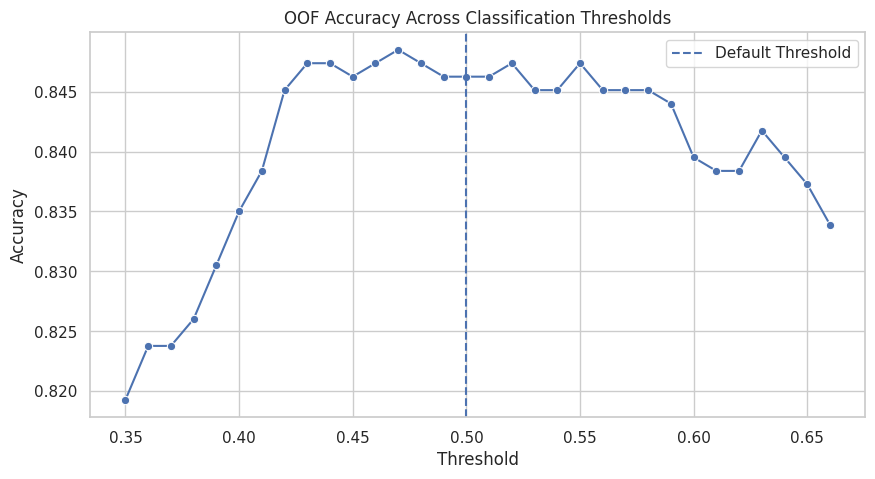

In [38]:
plt.figure(
    figsize=(10, 5)
)


sns.lineplot(

    data=threshold_df,

    x="Threshold",

    y="Accuracy",

    marker="o"
)


plt.axvline(

    0.5,

    linestyle="--",

    label="Default Threshold"
)


plt.title(
    "OOF Accuracy Across Classification Thresholds"
)


plt.legend()


plt.show()

# 12. Train Final Phase 11 Models

We will now fit every candidate model using the complete labeled training dataset.

The cross-fitted group survival features for training passengers remain out-of-fold estimates.

The test group survival features were generated exclusively from labeled training passengers.

This produces the final probability predictions required for Kaggle submissions.

In [39]:
X_test_group = test_struct[
    group_features
].copy()


test_probability_store = {}

final_fitted_models = {}


for model_name, model in (
    candidate_models.items()
):

    print(
        f"Training final "
        f"{model_name}"
    )


    pipeline = Pipeline(

        steps=[

            (
                "preprocessor",

                create_preprocessor(
                    group_features
                )
            ),

            (
                "classifier",

                clone(
                    model
                )
            )
        ]
    )


    pipeline.fit(

        X_group,

        y
    )


    test_probability_store[
        model_name
    ] = (

        pipeline

        .predict_proba(

            X_test_group
        )[:, 1]
    )


    final_fitted_models[
        model_name
    ] = pipeline

Training final Logistic Regression
Training final Random Forest
Training final Extra Trees
Training final Gradient Boosting


In [40]:
ensemble_test_probabilities = (

    best_ensemble[
        "Weight A"
    ]

    *

    test_probability_store[

        best_ensemble[
            "Model A"
        ]
    ]

    +

    best_ensemble[
        "Weight B"
    ]

    *

    test_probability_store[

        best_ensemble[
            "Model B"
        ]
    ]

    +

    best_ensemble[
        "Weight C"
    ]

    *

    test_probability_store[

        best_ensemble[
            "Model C"
        ]
    ]
)


ensemble_test_predictions = (

    ensemble_test_probabilities

    >= 0.5

).astype(int)

# 13. Conservative Group-Based Post-Processing

Machine learning models may sometimes predict an individual passenger differently from a very strong known group pattern.

We will create one experimental hybrid submission.

The rule will only activate when:

- At least two labeled group members are known.
- The group survival signal is extremely strong.

Strong survival signal:

`GroupSurvivalSignal >= 0.80`

Strong non-survival signal:

`GroupSurvivalSignal <= 0.20`

The standard ensemble submission will remain unchanged.

This hybrid submission will be evaluated separately on Kaggle so that we can determine whether conservative group overrides improve generalization.

In [42]:
hybrid_predictions = (

    ensemble_test_predictions.copy()
)


reliable_group_count = (

    test_struct[
        "FamilyKnownCount"
    ]

    +

    test_struct[
        "TicketKnownCount"
    ]
)


strong_survival = (

    (
        reliable_group_count
        >= 2
    )

    &

    (
        test_struct[
            "GroupSurvivalSignal"
        ]
        >= 0.80
    )
)


strong_non_survival = (

    (
        reliable_group_count
        >= 2
    )

    &

    (
        test_struct[
            "GroupSurvivalSignal"
        ]
        <= 0.20
    )
)


hybrid_predictions[
    strong_survival.values
] = 1


hybrid_predictions[
    strong_non_survival.values
] = 0


print(
    "Strong survival overrides:",
    strong_survival.sum()
)


print(
    "Strong non-survival overrides:",
    strong_non_survival.sum()
)


print(
    "Predictions changed:",
    np.sum(

        hybrid_predictions

        !=

        ensemble_test_predictions
    )
)

Strong survival overrides: 0
Strong non-survival overrides: 15
Predictions changed: 0


# 14. Demographic-Guarded Group Hybrid

We will create a second hybrid strategy.

This version applies group information differently depending on passenger demographics.

The purpose is to avoid overriding strong Titanic demographic patterns too aggressively.

Rules:

- Strong family/group survival evidence may rescue a prediction.
- Strong group non-survival evidence may reverse a prediction.
- Overrides are applied only when the group signal is supported by known labeled group members.

This submission is experimental and will be compared independently with the pure ensemble.

In [43]:
demographic_hybrid = (

    ensemble_test_predictions.copy()
)


female_mask = (

    test_struct[
        "Sex"
    ]
    == "female"
)


male_mask = (

    test_struct[
        "Sex"
    ]
    == "male"
)


reliable_family = (

    test_struct[
        "FamilyKnownCount"
    ]
    >= 1
)


reliable_ticket = (

    test_struct[
        "TicketKnownCount"
    ]
    >= 1
)


reliable_any_group = (

    reliable_family

    |

    reliable_ticket
)


female_strong_death = (

    female_mask

    &

    reliable_any_group

    &

    (
        test_struct[
            "GroupSurvivalSignal"
        ]
        < 0.20
    )
)


male_strong_survival = (

    male_mask

    &

    reliable_any_group

    &

    (
        test_struct[
            "GroupSurvivalSignal"
        ]
        > 0.80
    )
)


demographic_hybrid[
    female_strong_death.values
] = 0


demographic_hybrid[
    male_strong_survival.values
] = 1


print(
    "Female strong-death overrides:",
    female_strong_death.sum()
)


print(
    "Male strong-survival overrides:",
    male_strong_survival.sum()
)


print(
    "Total changed predictions:",
    np.sum(

        demographic_hybrid

        !=

        ensemble_test_predictions
    )
)

Female strong-death overrides: 6
Male strong-survival overrides: 0
Total changed predictions: 0


In [45]:
def create_and_validate_submission(
    predictions,
    filename
):

    submission = pd.DataFrame({

        "PassengerId":
            test_passenger_ids,

        "Survived":
            predictions.astype(int)
    })


    assert len(
        submission
    ) == len(
        test_raw
    )


    assert submission[
        "PassengerId"
    ].is_unique


    assert submission[
        "Survived"
    ].isna().sum() == 0


    assert set(

        submission[
            "Survived"
        ].unique()

    ).issubset(
        {0, 1}
    )


    path = (

        submissions_dir

        /

        filename
    )


    submission.to_csv(

        path,

        index=False
    )


    print(
        f"Saved: {path}"
    )


    return submission

In [46]:
submission_group_ensemble = (

    create_and_validate_submission(

        ensemble_test_predictions,

        "submission_phase11_group_ensemble.csv"
    )
)

Saved: ../submissions/submission_phase11_group_ensemble.csv


In [47]:
submission_group_hybrid = (

    create_and_validate_submission(

        hybrid_predictions,

        "submission_phase11_group_hybrid.csv"
    )
)

Saved: ../submissions/submission_phase11_group_hybrid.csv


In [48]:
submission_demographic_hybrid = (

    create_and_validate_submission(

        demographic_hybrid,

        "submission_phase11_demographic_hybrid.csv"
    )
)

Saved: ../submissions/submission_phase11_demographic_hybrid.csv


In [49]:
best_individual_name = (

    oof_results_df

    .iloc[0][
        "Model"
    ]
)


best_individual_predictions = (

    test_probability_store[
        best_individual_name
    ]

    >= 0.5

).astype(int)


submission_best_individual = (

    create_and_validate_submission(

        best_individual_predictions,

        "submission_phase11_best_individual.csv"
    )
)


print(
    f"Best individual model: "
    f"{best_individual_name}"
)

Saved: ../submissions/submission_phase11_best_individual.csv
Best individual model: Gradient Boosting


# 15. Compare Phase 11 Submission Candidates

Before uploading multiple files to Kaggle, we should determine whether the submissions actually contain meaningfully different predictions.

If two files differ by only one or two passengers, their leaderboard scores may be identical.

We will compare every Phase 11 candidate against the pure group ensemble.

In [51]:
submission_comparison = pd.DataFrame({

    "Submission": [

        "Best Individual",

        "Group Ensemble",

        "Group Hybrid",

        "Demographic Hybrid"
    ],

    "Predicted Survivors": [

        best_individual_predictions.sum(),

        ensemble_test_predictions.sum(),

        hybrid_predictions.sum(),

        demographic_hybrid.sum()
    ],

    "Differences vs Group Ensemble": [

        np.sum(

            best_individual_predictions

            !=

            ensemble_test_predictions
        ),

        0,

        np.sum(

            hybrid_predictions

            !=

            ensemble_test_predictions
        ),

        np.sum(

            demographic_hybrid

            !=

            ensemble_test_predictions
        )
    ]
})


submission_comparison

,Submission,Predicted Survivors,Differences vs Group Ensemble
0,Best Individual,151,21
1,Group Ensemble,144,0
2,Group Hybrid,144,0
3,Demographic Hybrid,144,0


In [52]:
oof_results_df.to_csv(

    results_dir

    /

    "phase11_model_comparison.csv",

    index=False
)


ensemble_search_df.to_csv(

    results_dir

    /

    "phase11_ensemble_search.csv",

    index=False
)


threshold_df.to_csv(

    results_dir

    /

    "phase11_threshold_analysis.csv",

    index=False
)


coverage_summary.to_csv(

    results_dir

    /

    "phase11_group_signal_coverage.csv",

    index=False
)


submission_comparison.to_csv(

    results_dir

    /

    "phase11_submission_comparison.csv",

    index=False
)


print(
    "Phase 11 experiment results saved."
)

Phase 11 experiment results saved.


In [53]:
print(
    "=" * 70
)

print(
    "PHASE 11 FINAL RESULTS"
)

print(
    "=" * 70
)


print(
    "\nModel Comparison:"
)


display(

    oof_results_df.round(4)
)


print(
    "\nBest Ensemble:"
)


display(
    best_ensemble
)


print(
    "\nSubmission Comparison:"
)


display(
    submission_comparison
)

PHASE 11 FINAL RESULTS

Model Comparison:


,Model,OOF Accuracy,OOF Log Loss,Fold Mean,Fold Std,Fold Min,Fold Max
0,Gradient Boosting,0.8474,0.3756,0.8474,0.0136,0.8202,0.8547
1,Random Forest,0.8462,0.3755,0.8462,0.0122,0.8315,0.8596
2,Extra Trees,0.8451,0.3814,0.8451,0.0133,0.8258,0.8603
3,Logistic Regression,0.8350,0.3954,0.8350,0.0142,0.8090,0.8492



Best Ensemble:


Model A     Logistic Regression
Weight A                    0.0
Model B           Random Forest
Weight B                    1.0
Model C             Extra Trees
Weight C                    0.0
Accuracy                0.84624
Log Loss               0.375519
Name: 0, dtype: object


Submission Comparison:


,Submission,Predicted Survivors,Differences vs Group Ensemble
0,Best Individual,151,21
1,Group Ensemble,144,0
2,Group Hybrid,144,0
3,Demographic Hybrid,144,0
